In [20]:
import earthaccess
import odc.stac
import pyproj
import pystac_client
import rasterio
from shapely.geometry import box
from shapely.ops import transform

In [45]:
CMR_STAC_URL = "https://cmr.earthdata.nasa.gov/stac/LPCLOUD"

catalog = pystac_client.Client.open(CMR_STAC_URL)

HLS_COLLECTION_IDS = ["HLSL30_2.0", "HLSS30_2.0"]

URL_PREFIX = "https://data.lpdaac.earthdatacloud.nasa.gov/"

In [47]:
auth = earthaccess.login(strategy="interactive", persist=True)
s3_creds = auth.get_s3_credentials("LPDAAC")

odc.stac.configure_rio(
    cloud_defaults=True,
    aws=dict(
        aws_access_key_id=s3_creds["accessKeyId"],
        aws_secret_access_key=s3_creds["secretAccessKey"],
        aws_session_token=s3_creds["sessionToken"],
        region_name="us-west-2",
    )
)

In [48]:
# my CRS of choice for CONUS these days
CRS_STRING = "epsg:5070"
EPSG = pyproj.CRS.from_string(CRS_STRING).to_epsg()

# Some nice fall dates
START_DATE = "2024-09-15"
END_DATE = "2024-10-08"

def convert_to_s3_uri(url: str) -> str:
    return url.replace(
        URL_PREFIX,
        "s3://"
    )

# bounding box that surrounds the North Shore of Lake Superior
xmin, ymin = 325000, 2750000
bbox = (xmin, ymin, xmin + 100000, ymin + 100000)
aoi = box(*bbox)

# STAC items store bounding box info in epsg:4326
transformer_4326 = pyproj.Transformer.from_crs(
    crs_from=CRS_STRING,
    crs_to="epsg:4326",
    always_xy=True,
)

bbox_4326 = transform(transformer_4326.transform, aoi).bounds

stac_items = catalog.search(
    collections=HLS_COLLECTION_IDS,
    bbox=bbox_4326,
    datetime=[START_DATE, END_DATE],
    limit=100,
).item_collection()

In [49]:
for item in stac_items:
    for asset in item.assets.values():
        if asset.href.startswith(URL_PREFIX):
            asset.href = convert_to_s3_uri(asset.href)

stac_items[0].assets["B04"].href

's3://lp-prod-protected/HLSL30.020/HLS.L30.T15UWP.2024259T165128.v2.0/HLS.L30.T15UWP.2024259T165128.v2.0.B04.tif'

In [50]:
HLS_ODC_STAC_CONFIG = {
    "HLSL30_2.0": {
        "assets": {
            "*": {
                "nodata": -9999,
                "data_type": "int16",
            },
            "Fmask": {
                "nodata": 0,
                "data_type": "uint8",
            },
        },
        "aliases": {
            "coastal_aerosol": "B01",
            "blue": "B02",
            "green": "B03",
            "red": "B04",
            "nir_narrow": "B05",
            "swir_1": "B06",
            "swir_2": "B07",
            "cirrus": "B09",
            "thermal_infrared_1": "B10",
            "thermal": "B11",
        },
    },
    "HLSS30_2.0": {
        "assets": {
            "*": {
                "nodata": -9999,
                "dtype": "int16",
            },
            "Fmask": {
                "nodata": 0,
                "dtype": "uint8",
            },
        },
        "aliases": {
            "coastal_aerosol": "B01",
            "blue": "B02",
            "green": "B03",
            "red": "B04",
            "red_edge_1": "B05",
            "red_edge_2": "B06",
            "red_edge_3": "B07",
            "nir_broad": "B08",
            "nir_narrow": "B8A",
            "water_vapor": "B09",
            "cirrus": "B10",
            "swir_1": "B11",
            "swir_2": "B12",
        },
    },
}

# these are the ones that we are going to use
BANDS = ["red", "green", "blue", "Fmask"]

stack = odc.stac.load(
    stac_items,
    stac_cfg=HLS_ODC_STAC_CONFIG,
    bands=BANDS,
    crs=CRS_STRING,
    resolution=60,
    chunks={},  # <-- use Dask
    groupby="solar_day",
    x=(bbox[0], bbox[2]),
    y=(bbox[1], bbox[3]),
    patch_url=convert_to_s3_uri,
)
display(stack)

<xarray.Dataset> Size: 292MB
Dimensions:      (y: 1667, x: 1668, time: 15)
Coordinates:
  * y            (y) float64 13kB 2.85e+06 2.85e+06 ... 2.75e+06 2.75e+06
  * x            (x) float64 13kB 3.25e+05 3.25e+05 ... 4.25e+05 4.25e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 120B 2024-09-15T16:51:28.990000 ... 20...
Data variables:
    red          (time, y, x) int16 83MB dask.array<chunksize=(1, 1667, 1668), meta=np.ndarray>
    green        (time, y, x) int16 83MB dask.array<chunksize=(1, 1667, 1668), meta=np.ndarray>
    blue         (time, y, x) int16 83MB dask.array<chunksize=(1, 1667, 1668), meta=np.ndarray>
    Fmask        (time, y, x) uint8 42MB dask.array<chunksize=(1, 1667, 1668), meta=np.ndarray>

In [51]:
stack_ = stack.compute()

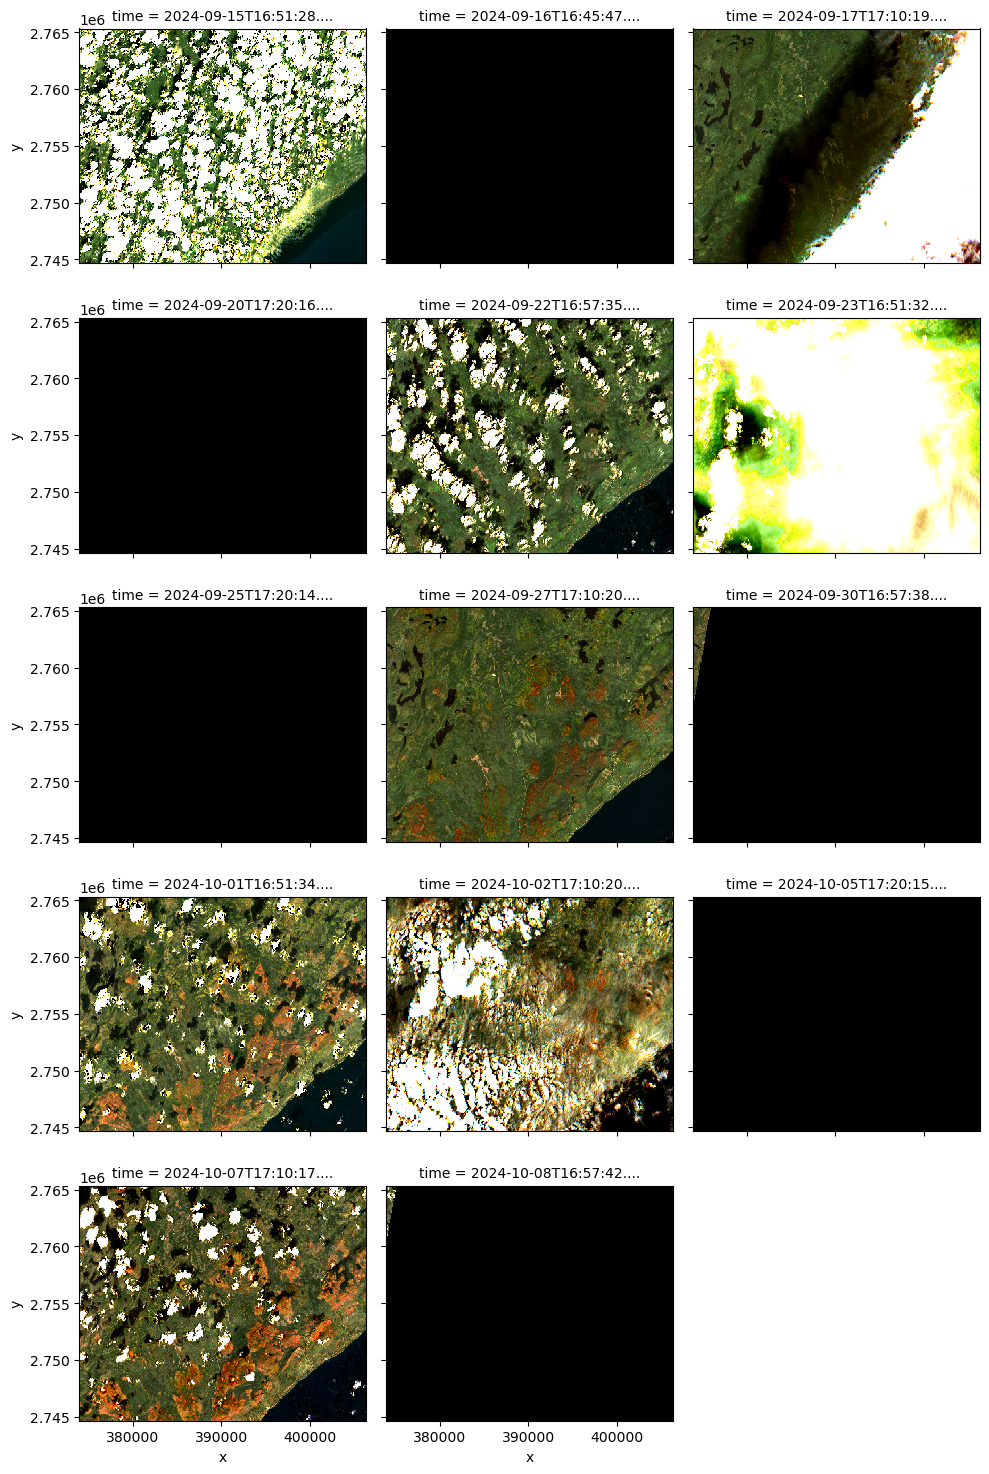

In [41]:
rgb = stack_.to_dataarray(dim="band").sel(band=["red", "green", "blue"])
rgb.plot.imshow(
    rgb="band",
    col="time",
    col_wrap=3,
    robust=True,
    vmin=0,
    vmax=1000,
)

In [8]:
def apply_gamma_correction(da, gamma=2.2, data_range=(0, 255)):
    """
    Apply gamma correction to an xarray DataArray containing RGB data.

    Parameters:
    - da: xarray DataArray with RGB data
    - gamma: gamma value (default 2.2)
    - data_range: tuple of (min, max) values in the data (default (0, 255))

    Returns:
    - xarray DataArray with gamma correction applied
    """
    # Ensure data is in float format
    da = da.astype(float)

    # Normalize data to 0-1 range
    da_normalized = (da - data_range[0]) / (data_range[1] - data_range[0])

    # Apply gamma correction
    da_corrected = da_normalized ** (1 / gamma)

    # Scale back to original range
    da_result = da_corrected * (data_range[1] - data_range[0]) + data_range[0]

    # Ensure we don't exceed the original data range
    da_result = da_result.clip(data_range[0], data_range[1])

    return da_result.astype(da.dtype)

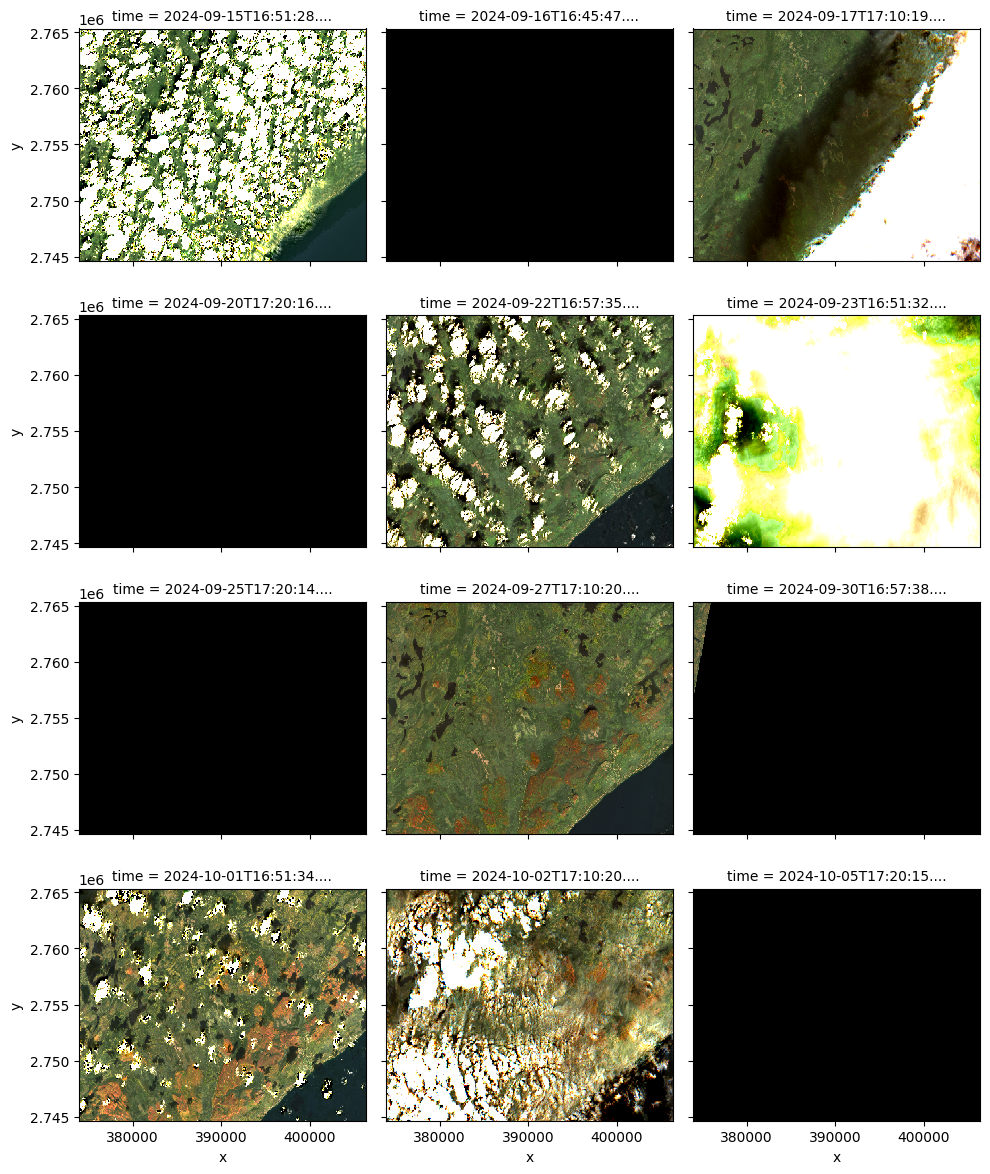

In [9]:
gamma_corrected = apply_gamma_correction(rgb, gamma=1.0, data_range=(-100, 1000))
gamma_corrected.plot.imshow(
    rgb="band",
    col="time",
    col_wrap=3,
    robust=True,
)

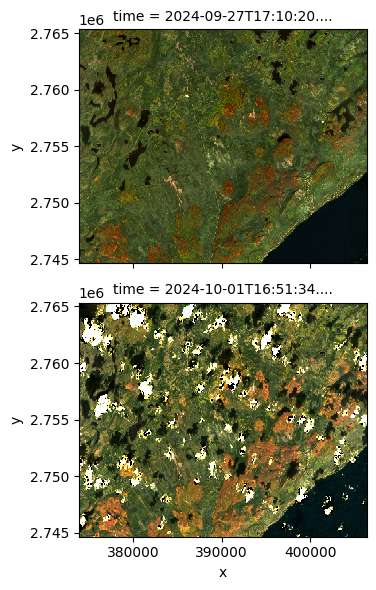

In [10]:
gamma_corrected.isel(time=[7, 9]).plot.imshow(
    rgb="band",
    row="time",
    robust=True,
    add_labels=False,
)